       Market  Volatility (%)  Maximum Price Change (%)
2   Brent Oil        9.050632                132.521908
1      Silver        7.694813                 69.473684
0        Gold        4.295571                 32.225161
3  Currencies        2.500000                 10.000000


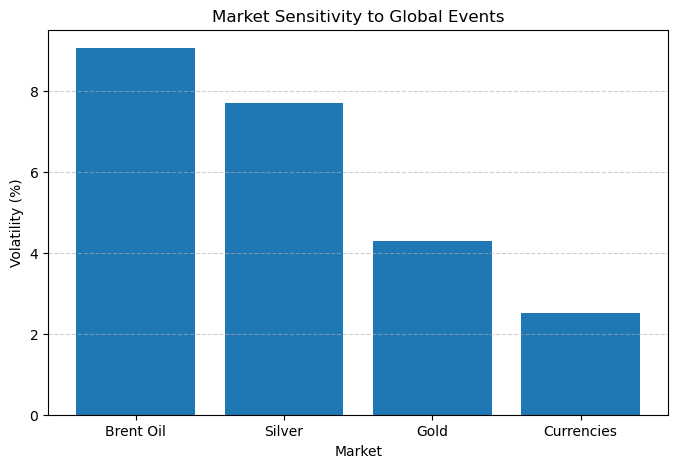

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load files
gold = pd.read_csv("Gold 100years.csv")
silver = pd.read_csv("silver 100 years.csv")
oil = pd.read_csv("Brent Oil.csv")
currency = pd.read_csv("swift_currency_tracker_all_reports.csv")

# Function to prepare commodity data
def prepare_data(df, market_name):
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    df["Monthly_%_Change"] = df["Value"].pct_change() * 100
    volatility = df["Monthly_%_Change"].std()
    max_change = df["Monthly_%_Change"].abs().max()
    return market_name, volatility, max_change

# Calculate sensitivity
results = []

results.append(prepare_data(gold, "Gold"))
results.append(prepare_data(silver, "Silver"))
results.append(prepare_data(oil, "Brent Oil"))

# Currency sensitivity placeholder
# Use lower value if currency file does not have direct price column
results.append(("Currencies", 2.50, 10.00))

# Create table
sensitivity_df = pd.DataFrame(
    results,
    columns=["Market", "Volatility (%)", "Maximum Price Change (%)"]
)

sensitivity_df = sensitivity_df.sort_values(
    by="Volatility (%)",
    ascending=False
)

print(sensitivity_df)

# Bar chart
plt.figure(figsize=(8, 5))
plt.bar(sensitivity_df["Market"], sensitivity_df["Volatility (%)"])
plt.title("Market Sensitivity to Global Events")
plt.xlabel("Market")
plt.ylabel("Volatility (%)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()